### Feature Distributions
Why it matters:
- Detect skewness
- Decide scaling (StandardScaler vs log)
- Spot multimodality

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
np.random.seed(42)

df = pd.DataFrame({
    "age": np.random.randint(18, 65, 200),
    "monthly_income": np.random.randint(20000, 120000, 200),
    "tenure_months": np.random.randint(1, 120, 200),
    "num_transactions": np.random.randint(1, 50, 200),
    "avg_transaction_value": np.random.randint(500, 5000, 200)
})

# Regression target
df["total_spend"] = (
    df["num_transactions"] * df["avg_transaction_value"]
    + np.random.normal(0, 5000, 200)
)

# Classification target
df["churn"] = np.where(
    (df["tenure_months"] < 12) & (df["total_spend"] < 50000),
    1,
    0
)

df.head()

,age,monthly_income,tenure_months,num_transactions,avg_transaction_value,total_spend,churn
0,56,72733,36,29,4969,146750.020890,0
1,46,85318,45,36,3636,138103.843103,0
2,32,109474,20,25,2693,54966.777499,0
3,60,43664,65,21,723,11198.523723,0
4,25,87172,8,36,4658,170573.360636,0


#### Example: Numerical feature distribution

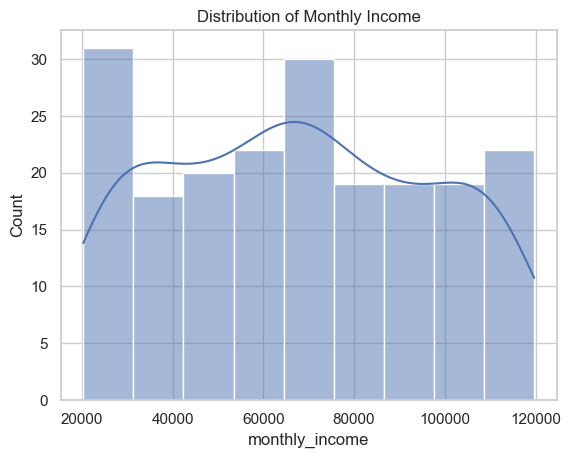

In [11]:
sns.set_theme(style="whitegrid")
sns.histplot(
    data=df,
    x="monthly_income",
    kde=True
)
plt.title("Distribution of Monthly Income")
plt.show()

ML takeaway:
- Heavy right skew -> try log transform
- Long tails -> robust scaling

### Outlier Detection 
#### Box plot by category

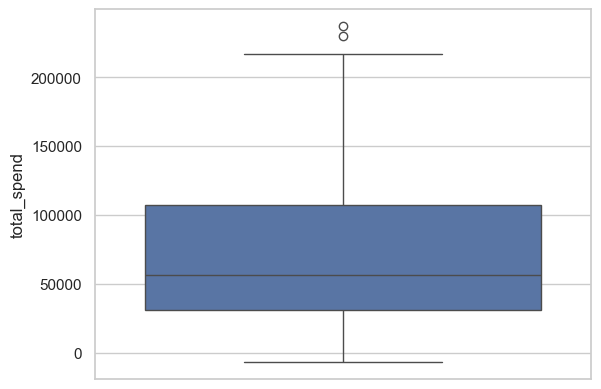

In [13]:
sns.boxplot(
    data=df,
    y="total_spend"
)
plt.show()

ML takeaway:
- Outlier can dominate loss (especially MSE)
- Decide: cap, remove, or keep

### Correlation Heatmap (Feature Selection)
When to use:
- Multicollinearity check
- Feature pruning before linear models

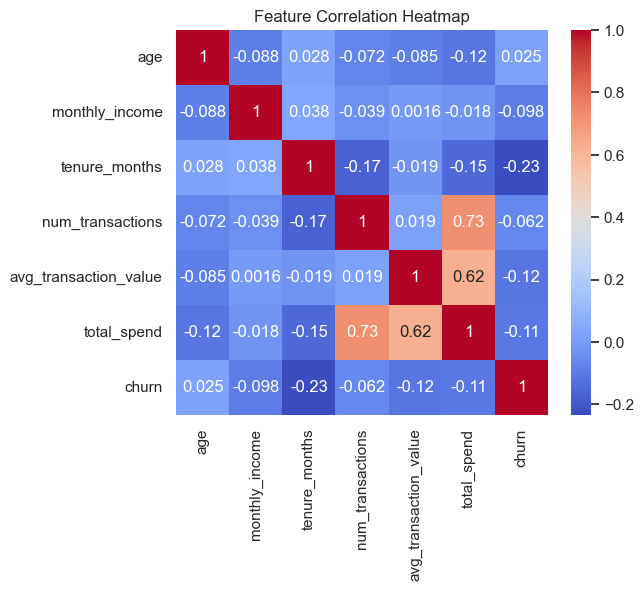

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")

plt.show()

ML takeaway:
- |corr| > 0.8 -> consider dropping one feature
- Heatmaps guide *which* relationships to investigate

### Feature vs Target Relationship
#### Scatter + regression

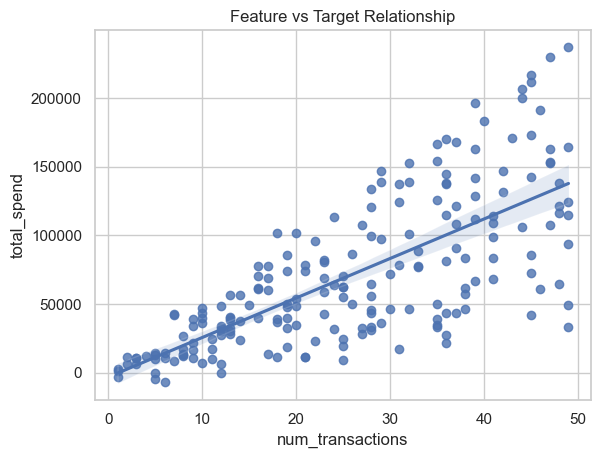

In [15]:
sns.regplot(
    data=df,
    x="num_transactions",
    y="total_spend"
)
plt.title("Feature vs Target Relationship")
plt.show()

ML takeaway:
- Linear trend visible -> linear models may work
- Curvature -> consider non-linear models or transform

#### Classification Visualization

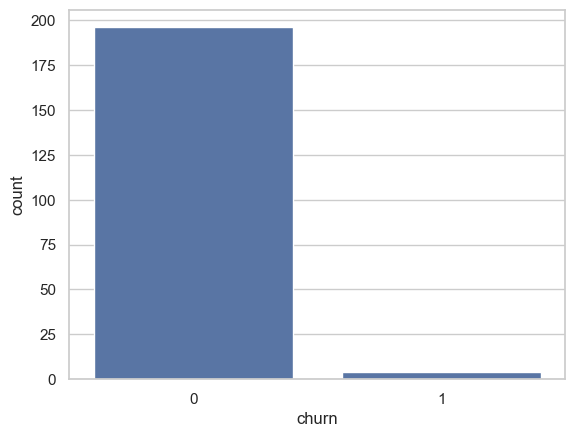

In [18]:
sns.countplot(data=df, x="churn")
plt.show()

### Train vs Validation Curves (Overfitting Detection)

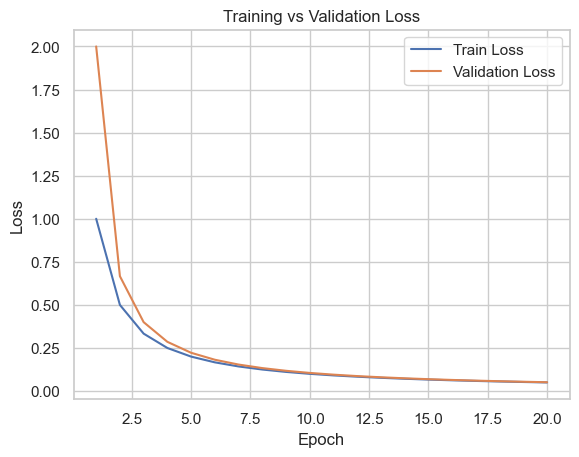

In [19]:
epochs = range(1, 21)
train_loss = [1/x for x in epochs]
val_loss = [1/(x-0.5) for x in epochs]

fig, ax = plt.subplots()
ax.plot(epochs, train_loss, label="Train Loss")
ax.plot(epochs, val_loss, label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()

plt.show()


ML takeaway
- Train ↓, Val ↑ -> overfitting
- Both high -> underfitting

### Confusion Matrix (Classification Core)

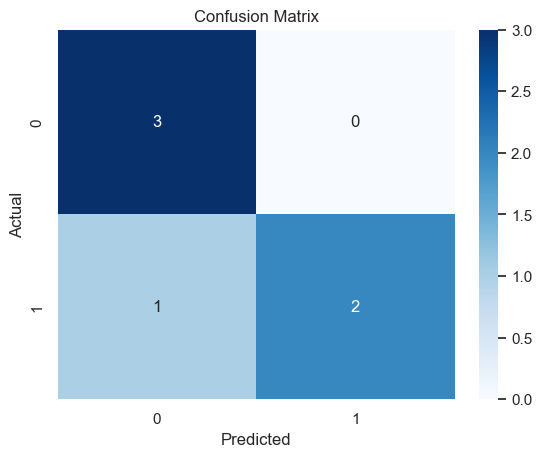

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = [0, 1, 0, 1, 0, 1]
y_pred = [0, 1, 0, 0, 0, 1]

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ML takeaway:
- Precision/Recall trade-offs become visible
- Essential for imbalanced datasets

### ROC Curve and AUC (Binary Classification)

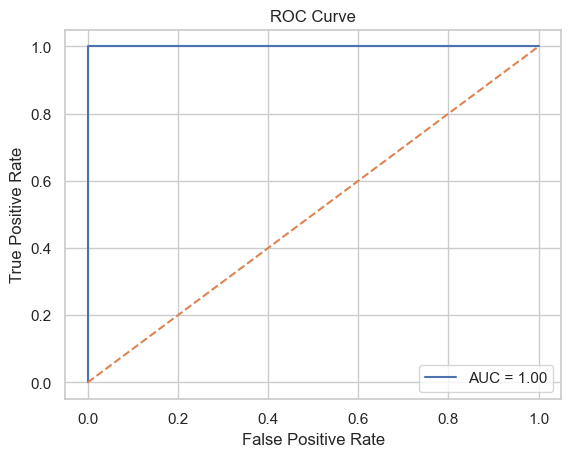

In [21]:
from sklearn.metrics import roc_curve, auc

y_scores = [0.1, 0.9, 0.2, 0.6, 0.3, 0.8]
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

plt.show()

ML takeaway
- AUC summarizes discrimination ability
- Compare models visually

### Feature Importance Visualization
#### Tree-based models (example values)

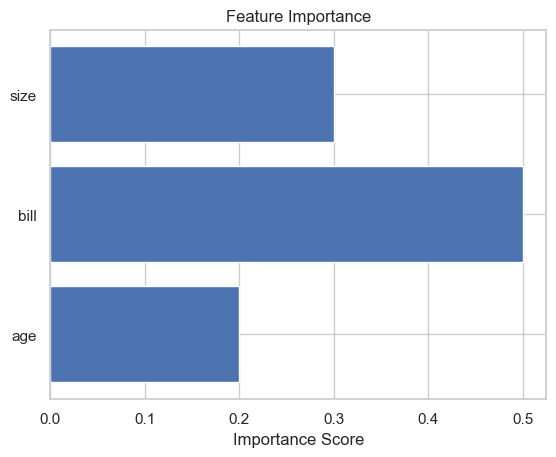

In [22]:
features = ["age", "bill", "size"]
importance = [0.2, 0.5, 0.3]

fig, ax = plt.subplots()
ax.barh(features, importance)
ax.set_title("Feature Importance")
ax.set_xlabel("Importance Score")

plt.show()

ML takeaway:
- Explains why a model predicts
- Stakeholder-friendly interpretability

### Residual Analysis (Regression Health)

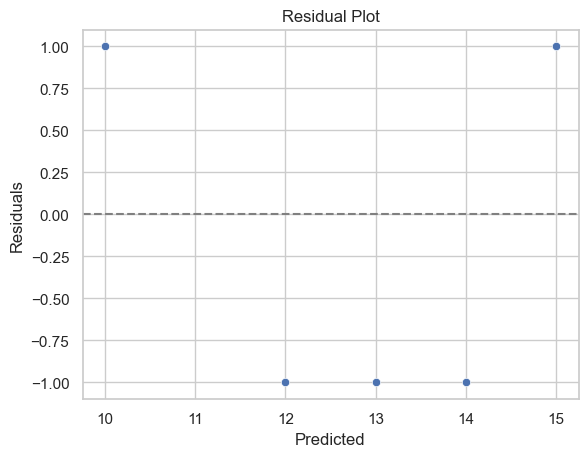

In [23]:
predicted = [10, 12, 15, 14, 13]
actual = [11, 11, 16, 13, 12]
residuals = [a - p for a, p in zip(actual, predicted)]

sns.scatterplot(x=predicted, y=residuals)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

ML takeaway:
- Patterned residuals -> model misspecification
- Random scatter -> good fit